In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
import scipy.stats as stats
warnings.filterwarnings('ignore')

#### fetching vendor summary data(table) which is optimised_table(from prev notebook) or vendor_sales_summary(from py file)
#### both are stored in inventory.db

In [3]:
#l0aod the dataset ie table
conn=sqlite3.connect('inventory.db')


df=pd.read_sql_query("SELECT * FROM vendor_sales_summary",conn)
df.head()

,Description,VendorName,VendorNumber,Brand,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TOtalsalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,TotalFreightCost,GrossProfit,ProfitMargin,StockTurnOver,SalestoPurchaseRatio
0,Jack Daniels No 7 Black,BROWN-FORMAN CORP,1128,1233,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,Tito's Handmade Vodka,MARTIGNETTI COMPANIES,4425,3405,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,Absolut 80 Proof,PERNOD RICARD USA,17035,8068,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,Capt Morgan Spiced Rum,DIAGEO NORTH AMERICA INC,3960,4261,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,Ketel One Vodka,DIAGEO NORTH AMERICA INC,3960,3545,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


# EDA on our final database(whole table)

In [4]:
df.describe().T
#.T is used to transpose

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TOtalsalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


* The X-axis (the column name): Divides the data's range into 30 even intervals (since you set bins=30).

* The Y-axis ("Count"): Shows how many rows in your dataframe have a value fitting inside that specific bin.

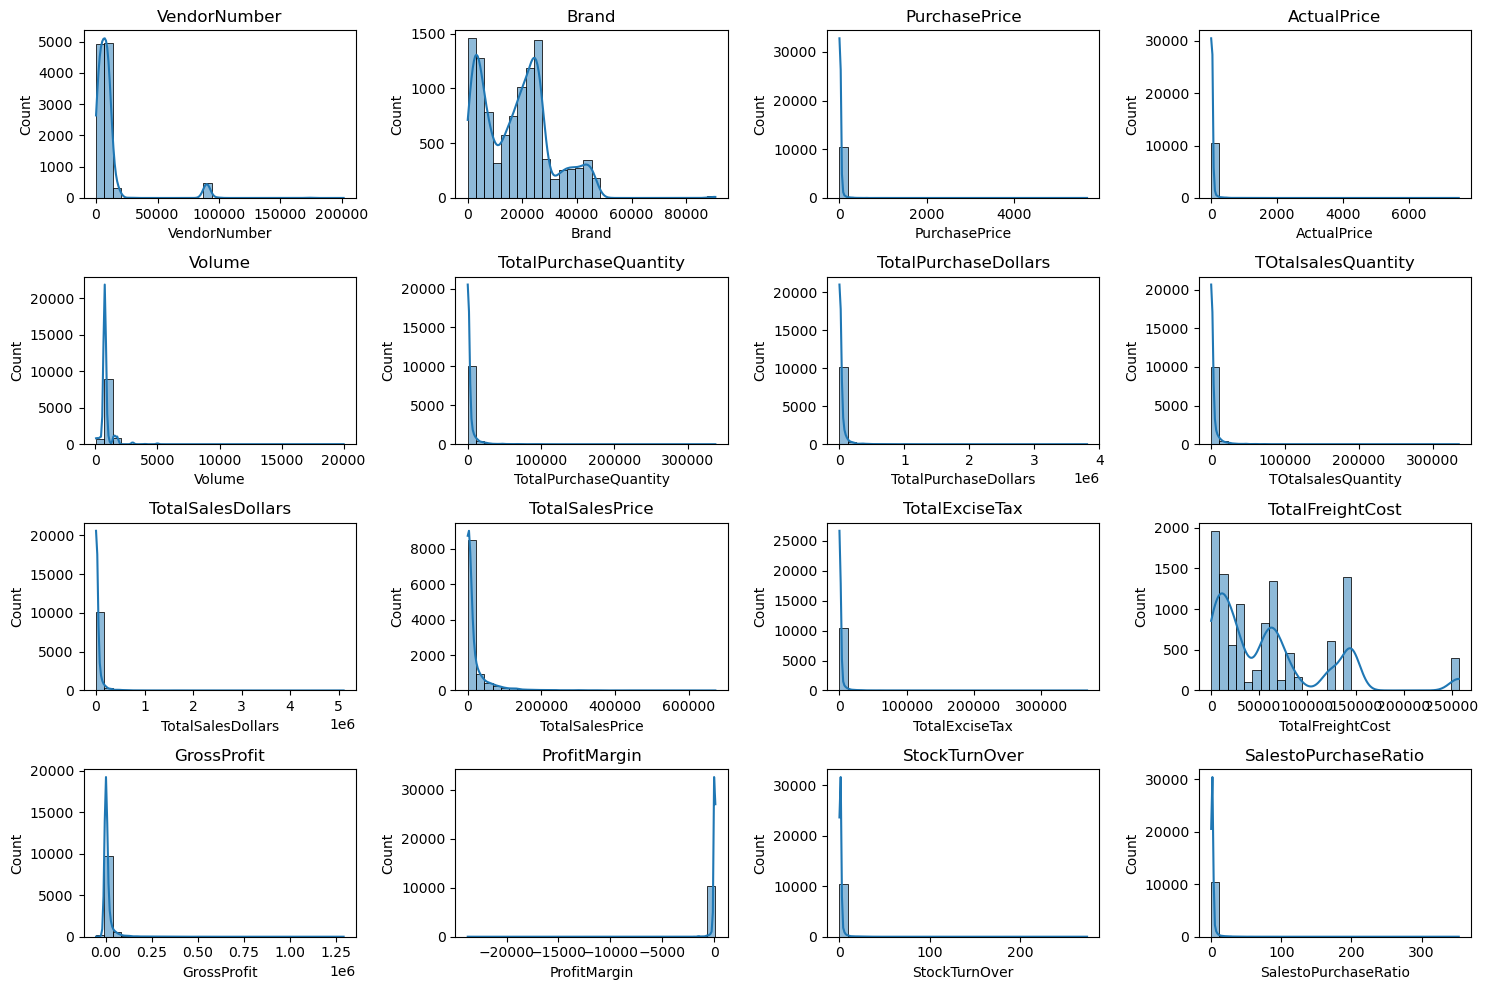

In [5]:
# Distribution plot for numerical columns
# plotting histogram for each column
num_col = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_col):  # loop through all the numerical columns
    plt.subplot(4, 4, i + 1)       # adjust grid layout
    sns.histplot(df[col], kde=True, bins=30)
    
    # Adding axes labels and title
    plt.title(col, fontsize=12)
    plt.xlabel(col, fontsize=10)       # X-axis gets the column/feature name
    plt.ylabel('Count', fontsize=10)   # Y-axis gets the frequency count

plt.tight_layout()
plt.show()

Box plot to see outliers

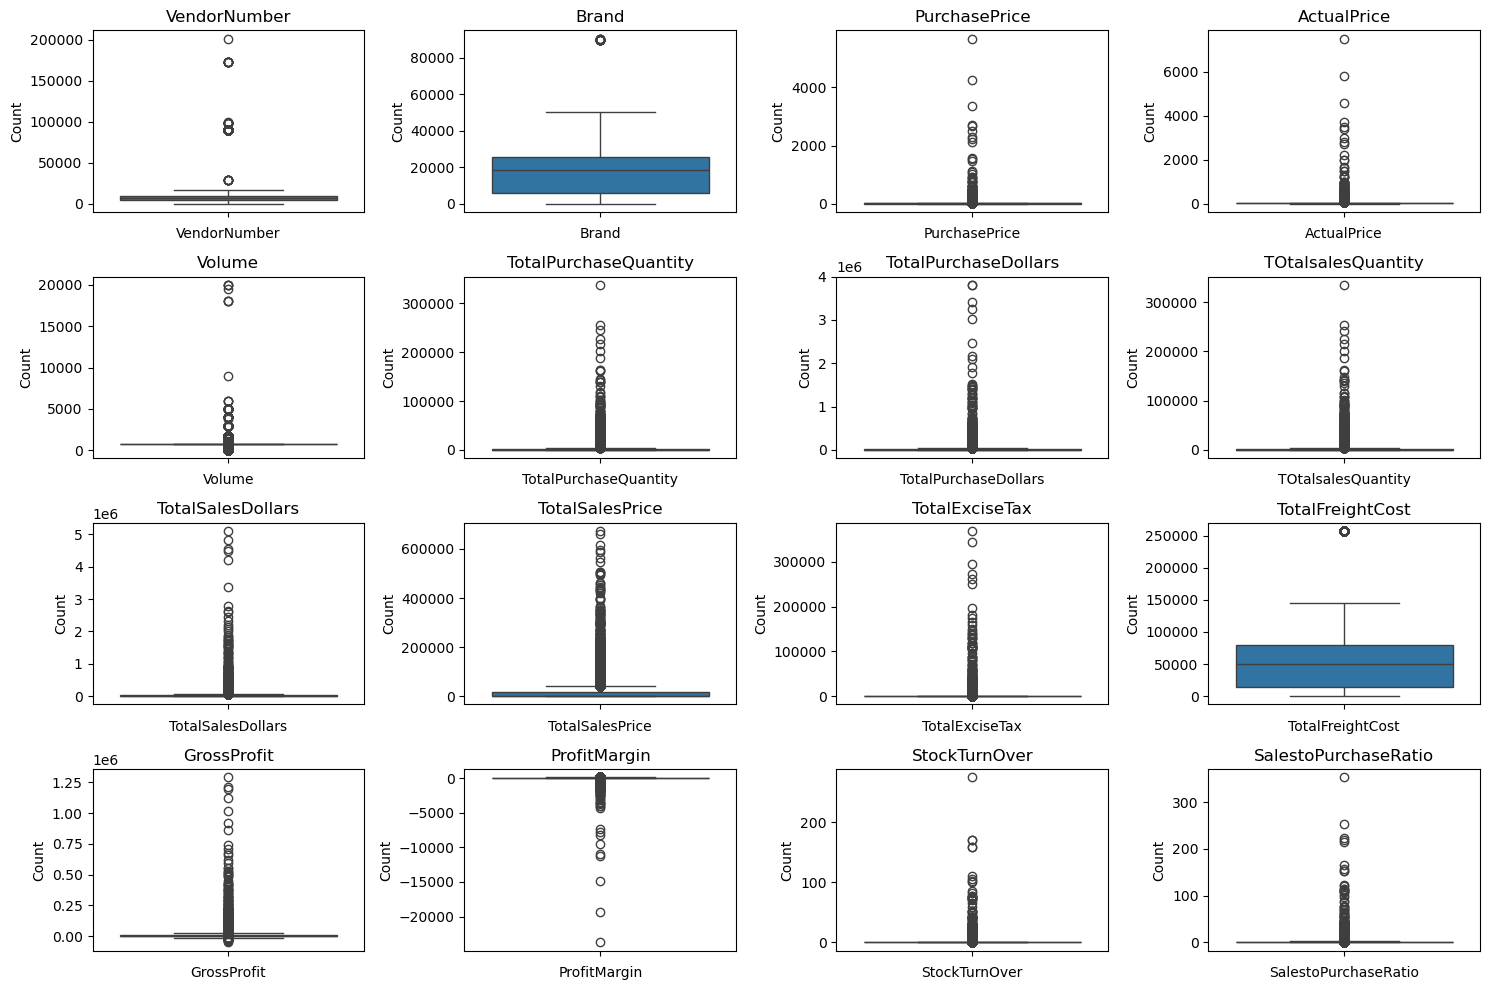

In [6]:
# Distribution plot for numerical columns
# plotting histogram for each column
num_col = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_col):  # loop through all the numerical columns
    plt.subplot(4, 4, i + 1)       # adjust grid layout
    sns.boxplot(y=df[col])
    
    # Adding axes labels and title
    plt.title(col, fontsize=12)
    plt.xlabel(col, fontsize=10)       # X-axis gets the column/feature name
    plt.ylabel('Count', fontsize=10)   # Y-axis gets the frequency count

plt.tight_layout()
plt.show()

## Summary Statistics Insights

**Negative & Zero Values:**

- **Gross Profit:** Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.
- **Profit Margin:** Has a minimum of -∞, which suggests cases where revenue is zero or even lower than costs.
- **Total Sales Quantity & Sales Dollars:** Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

**Outliers Indicated by High Standard Deviations:**

- **Purchase & Actual Prices:** The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.(OUTLIERS)
- **Freight Cost:** Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
- **Stock Turnover:** Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that Sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.(ie of previous year)

Here we will not remove all outlier
Since there might be premium products for whicfh price is too high and all
We will remove those products whicfh have not been solds(totalsalesquantiy=0)
or those who has borught 0 profit
* Wont consider product which has incurred losses


In [7]:
df=pd.read_sql_query("""SELECT *
                     FROM vendor_sales_summary
                     WHERE GrossProfit>0
                     AND TotalSalesQuantity>0
                     AND ProfitMargin>0
                     """,conn)
df['GrossProfit'].min()

0.03999999999999204

Now we plot again

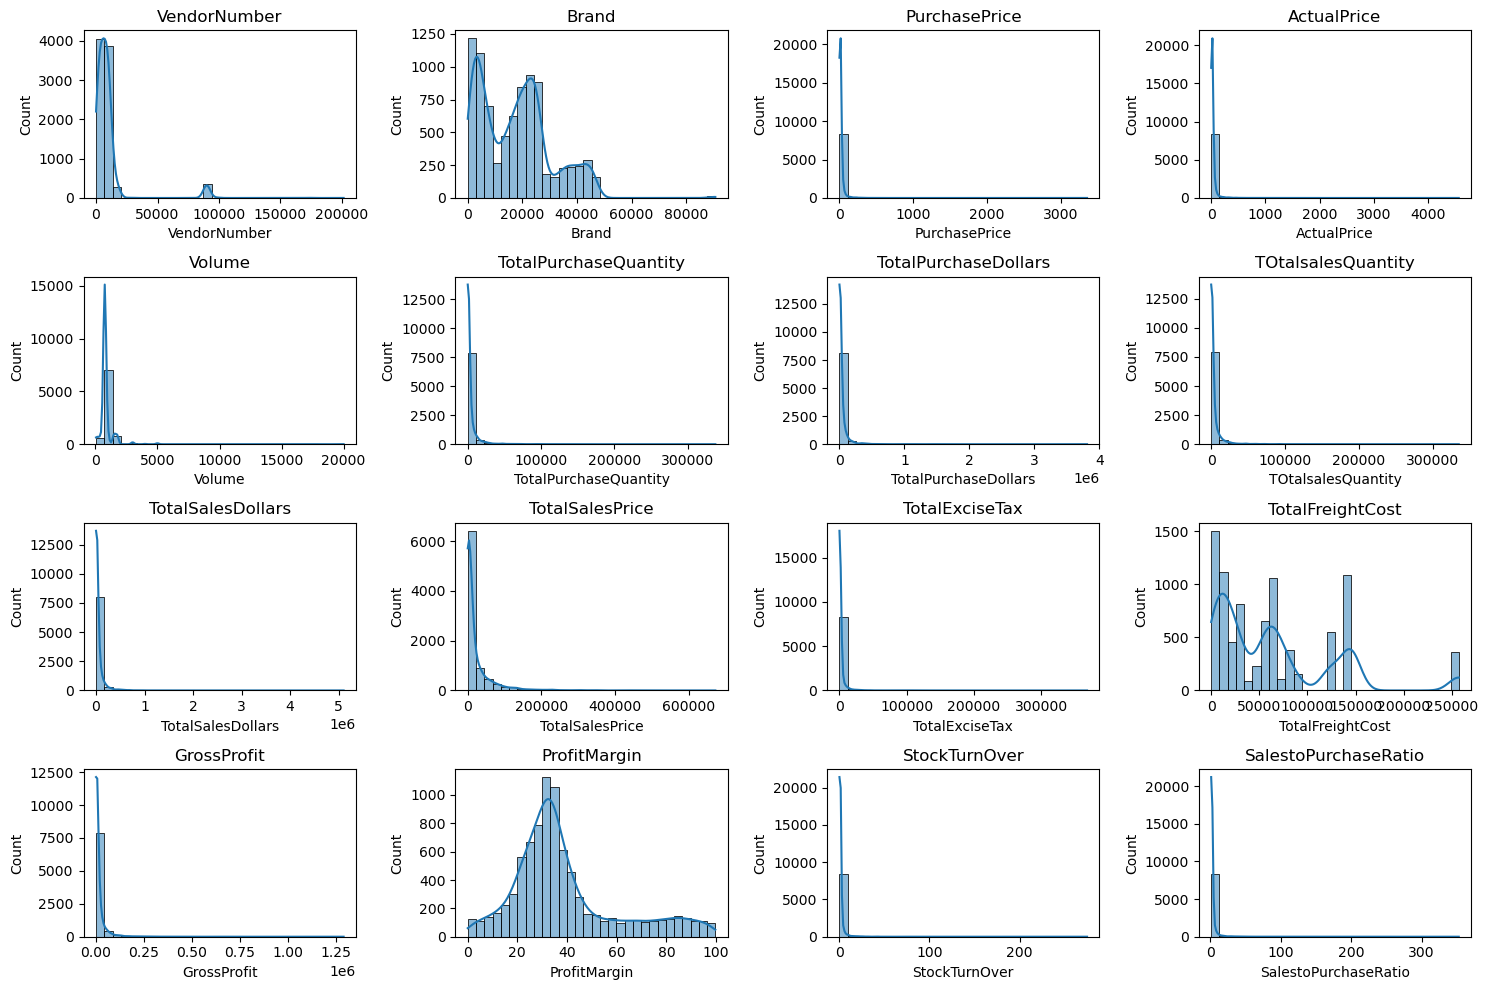

In [8]:
# Distribution plot for numerical columns
# plotting histogram for each column
num_col = df.select_dtypes(include=np.number).columns # or type the name of columns
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_col):  # loop through all the numerical columns
    plt.subplot(4, 4, i + 1)       # adjust grid layout
    sns.histplot(df[col], kde=True, bins=30)
    
    # Adding axes labels and title
    plt.title(col, fontsize=12)
    plt.xlabel(col, fontsize=10)       # X-axis gets the column/feature name
    plt.ylabel('Count', fontsize=10)   # Y-axis gets the frequency count

plt.tight_layout()
plt.show()

* which vendor contributes more and
* which product contributes more

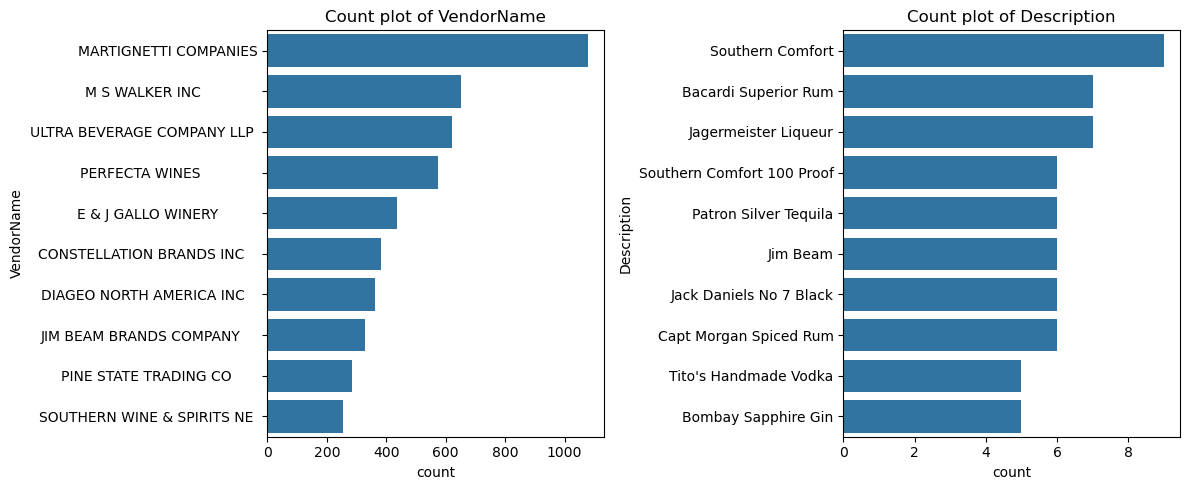

In [9]:
#Count plots for categorical columns
cat_col=["VendorName","Description"]
plt.figure(figsize=(12,5))
for i, col in enumerate(cat_col):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col],order=df[col].value_counts().index[:10]) # top 10 characters which dominate
    plt.title(f"Count plot of {col}")
plt.tight_layout()
plt.show()

Heatmap is the best way to plot the correlation between any two numerical variables of how they aRE DEPENDENT ON EACH OTHERR

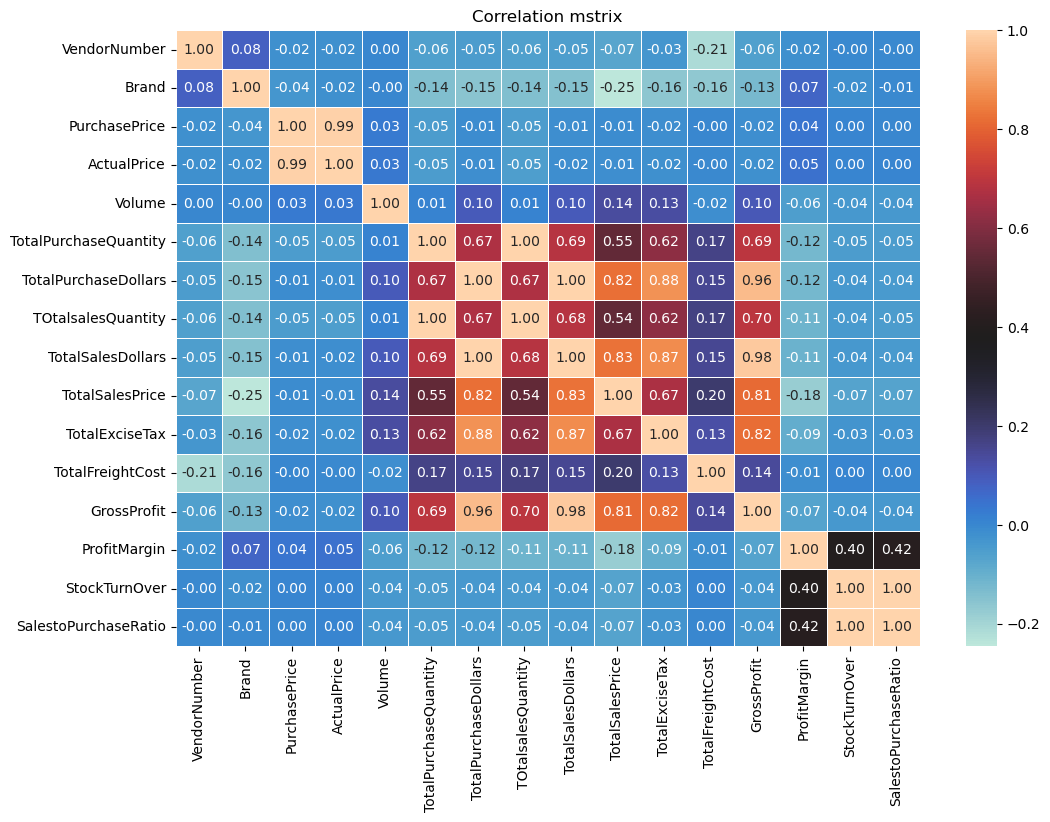

In [10]:
#Correlation Heatmap
plt.figure(figsize=(12,8))
corr_mat=df[num_col].corr()
sns.heatmap(corr_mat,annot=True,fmt=".2f",cmap="icefire",linewidth=0.6)
plt.title("Correlation mstrix")
plt.show()

## Correlation Insights

- **PurchasePrice** has weak correlations with TotalSalesDollars (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.
- Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.
- Negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.(imp pt)
- **StockTurnover** has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily result in higher profitability.

# Data Analysis


## Brand Performance

* Brands with lower sales perfomance but higher profit margins

In [62]:
brand_performance=df.groupby('Description').agg({'TotalSalesDollars':'sum','TOtalsalesQuantity':'sum','ProfitMargin':'mean'}).reset_index()
#it shows that von buhl in this chart has low totalsalesdollars but profite is massive
brand_performance

,Description,TotalSalesDollars,TOtalsalesQuantity,ProfitMargin
0,(RI) 1,21519.09,591.0,18.060661
1,.nparalleled Svgn Blanc,1094.63,137.0,29.978166
2,10 Span Cab Svgn CC,2703.89,361.0,20.937612
3,10 Span Chard CC,3325.56,444.0,27.806445
4,10 Span Pnt Gris Monterey Cy,2082.22,278.0,32.226182
...,...,...,...,...
7702,Zorvino Vyds Sangiovese,10579.03,847.0,29.525675
7703,Zuccardi Q Malbec,1639.18,82.0,23.981503
7704,Zum Rsl,10857.34,1066.0,32.675038
7705,Zwack Liqueur,227.88,12.0,16.653502


In [44]:
#less than 15%
low_sales_threshold=brand_performance['TotalSalesDollars'].quantile(0.15)
#profit margin greater than 85%
high_margin_threshold=brand_performance['ProfitMargin'].quantile(0.85)

"Any brand that generated less than $560.29 is in the bottom 15% of sales."

In [45]:
low_sales_threshold

np.float64(560.299)

Any brand with a profit margin higher than 65% (%profit) is in the top 15% of earners. ie in the  lower 85%"
It means 85% of your brands have a profit margin lower than this threshold, and only the top 15% of highly profitable brands sit above it.

In [46]:
high_margin_threshold

np.float64(64.97017552750113)

* TArget those brands with proft above 64$ and sales below 560$
* It dynamically identifies brands that have abnormally low sales but exceptionally high profit margins—precisely the kind of anomaly you noticed with "Von Buhl."

In [61]:
# Filter for brands that are BOTH in the bottom 15% for sales AND top 15% for profit margin
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) & 
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]

display(target_brands.sort_values('TotalSalesDollars'))

,Description,TotalSalesDollars,TOtalsalesQuantity,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,1.0,66.466466
2369,Debauchery Pnt Nr,11.58,2.0,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,5.0,83.448276
2188,Crown Royal Apple,27.86,14.0,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,4.0,82.153076
...,...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,32.0,76.747312
2271,Dad's Hat Rye Whiskey,538.89,11.0,81.851584
57,A Bichot Clos Marechaudes,539.94,6.0,67.740860
6245,Sbragia Home Ranch Merlot,549.75,25.0,66.444748


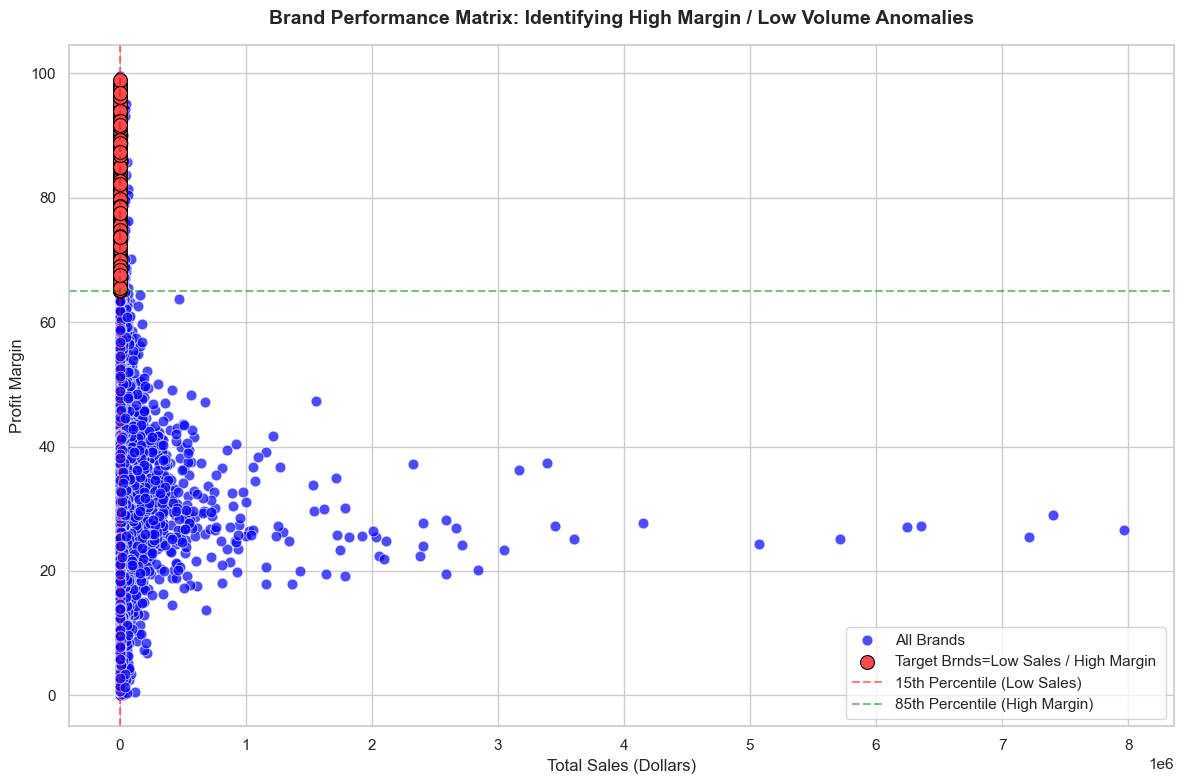

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns


# Set the plotting style and size
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# 1. Plot ALL brands in the background (using a soft gray)
sns.scatterplot(
    data=brand_performance,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='blue',
    alpha=0.7,
    s=60,
    label='All Brands'
)

# 2. Overlay the Target/Anomaly brands in a vibrant color
sns.scatterplot(
    data=target_brands,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='#FF4B4B',   # Bright Red/Coral
    alpha=1.0,
    s=100,             # Slightly larger size to stand out
    edgecolor='black', # Dark outline to make them pop
    label='Target Brnds=Low Sales / High Margin '
)

# 3. Draw dashed threshold lines to visually represent the quantiles
plt.axvline(x=low_sales_threshold, color='red', linestyle='--', alpha=0.5, label='15th Percentile (Low Sales)')
plt.axhline(y=high_margin_threshold, color='green', linestyle='--', alpha=0.5, label='85th Percentile (High Margin)')

# # 4. Optional: Label the specific target brands directly on the plot
# for idx, row in target_brands.iterrows():
#     plt.text(
#         x=row['TotalSalesDollars'] + (low_sales_threshold * 0.02), # Tiny offset to the right
#         y=row['ProfitMargin'], 
#         s=row['Description'], 
#         fontsize=9, 
#         weight='bold',
#         color='#333333'
#     )

# Formatting the plot
plt.title("Brand Performance Matrix: Identifying High Margin / Low Volume Anomalies", fontsize=14, pad=15, weight='bold')
plt.xlabel("Total Sales (Dollars)", fontsize=12)
plt.ylabel("Profit Margin", fontsize=12)
plt.legend(loc='lower right', frameon=True)

# Clean display
plt.tight_layout()
plt.show()

In [56]:
filteres=brand_performance[brand_performance['TotalSalesDollars']<1000] # for better visualisation

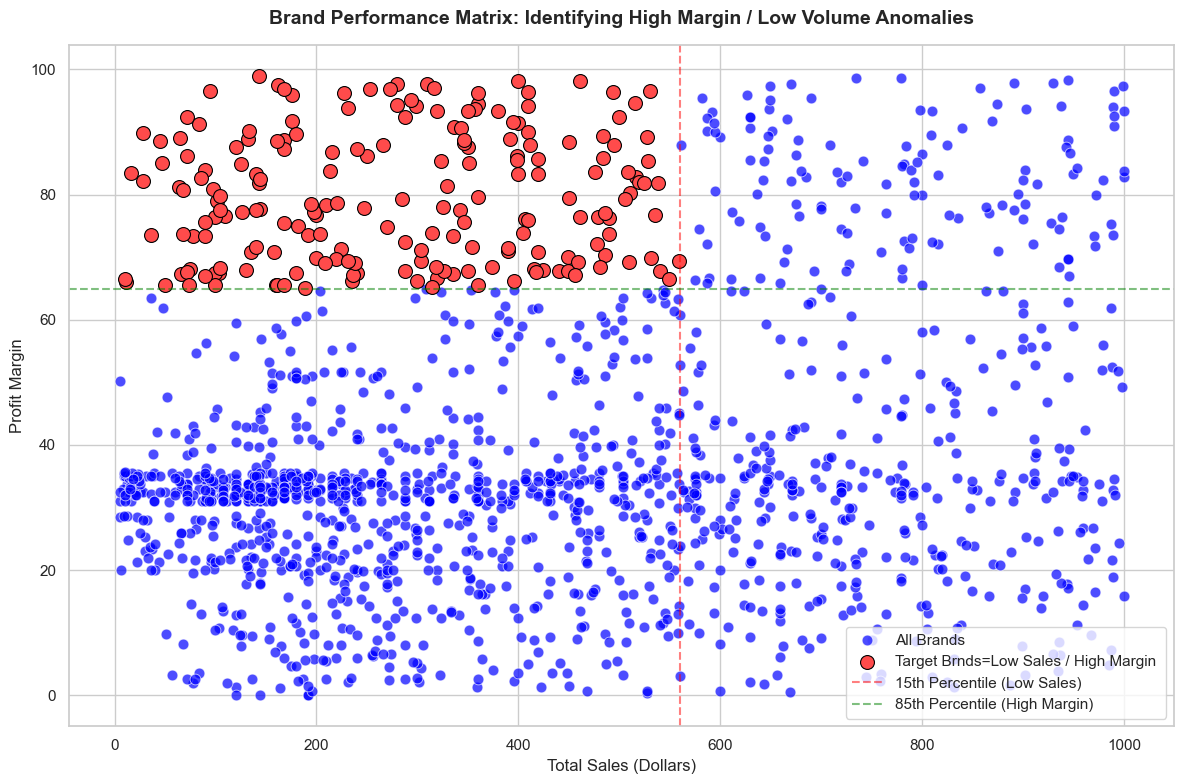

In [64]:


# Set the plotting style and size
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# 1. Plot ALL brands in the background (using a soft gray)
sns.scatterplot(data=filteres,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='blue',
    alpha=0.7,
    s=60,
    label='All Brands'
)

# 2. Overlay the Target/Anomaly brands in a vibrant color
sns.scatterplot(
    data=target_brands,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='#FF4B4B',   # Bright Red/Coral
    alpha=1.0,
    s=100,             # Slightly larger size to stand out
    edgecolor='black', # Dark outline to make them pop
    label='Target Brnds=Low Sales / High Margin '
)

# 3. Draw dashed threshold lines to visually represent the quantiles
plt.axvline(x=low_sales_threshold, color='red', linestyle='--', alpha=0.5, label='15th Percentile (Low Sales)')
plt.axhline(y=high_margin_threshold, color='green', linestyle='--', alpha=0.5, label='85th Percentile (High Margin)')

# # 4. Optional: Label the specific target brands directly on the plot
# for idx, row in target_brands.iterrows():
#     plt.text(
#         x=row['TotalSalesDollars'] + (low_sales_threshold * 0.02), # Tiny offset to the right
#         y=row['ProfitMargin'], 
#         s=row['Description'], 
#         fontsize=9, 
#         weight='bold',
#         color='#333333'
#     )

# Formatting the plot
plt.title("Brand Performance Matrix: Identifying High Margin / Low Volume Anomalies", fontsize=14, pad=15, weight='bold')
plt.xlabel("Total Sales (Dollars)", fontsize=12)
plt.ylabel("Profit Margin", fontsize=12)
plt.legend(loc='lower right', frameon=True)

# Clean display
plt.tight_layout()
plt.show()

Vendors and Brands with highest sale performance

In [90]:
#Function to convert 1000 to K and 100000to M
def format_dollar(value):
    if(value>=1_000_000):
     return f"{value/1_000_000:.2f}M"
    elif(value>=1_000):
     return f"{value/1_000:.2f}K"
    else:
      return str(value)
    

In [86]:
#Top vendors
top_vendors=df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands=df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors.apply(lambda x:format_dollar(x))

VendorName
DIAGEO NORTH AMERICA INC       67.99M
MARTIGNETTI COMPANIES          39.28M
PERNOD RICARD USA              32.06M
JIM BEAM BRANDS COMPANY        31.42M
BACARDI USA INC                24.85M
CONSTELLATION BRANDS INC       24.22M
E & J GALLO WINERY             18.40M
BROWN-FORMAN CORP              18.25M
ULTRA BEVERAGE COMPANY LLP     16.50M
M S WALKER INC                 14.71M
Name: TotalSalesDollars, dtype: object

In [87]:
#apply the fucntion to transform
top_brands.apply(lambda x:format_dollar(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

* SAME THING WITH SQL

In [82]:
# pd.read_sql_query("""SELECT VendorName, sum(TotalSalesDollars) AS TotalSumSalesDollars FROM vendor_sales_summary 
#                   GROUP BY VendorName 
#                   ORDER BY TotalSumSalesDollars DESC 
#                   LIMIT 10 """,conn)

In [85]:
# top_brands

Bar plots for top 10 brands and top 10  BY SALES

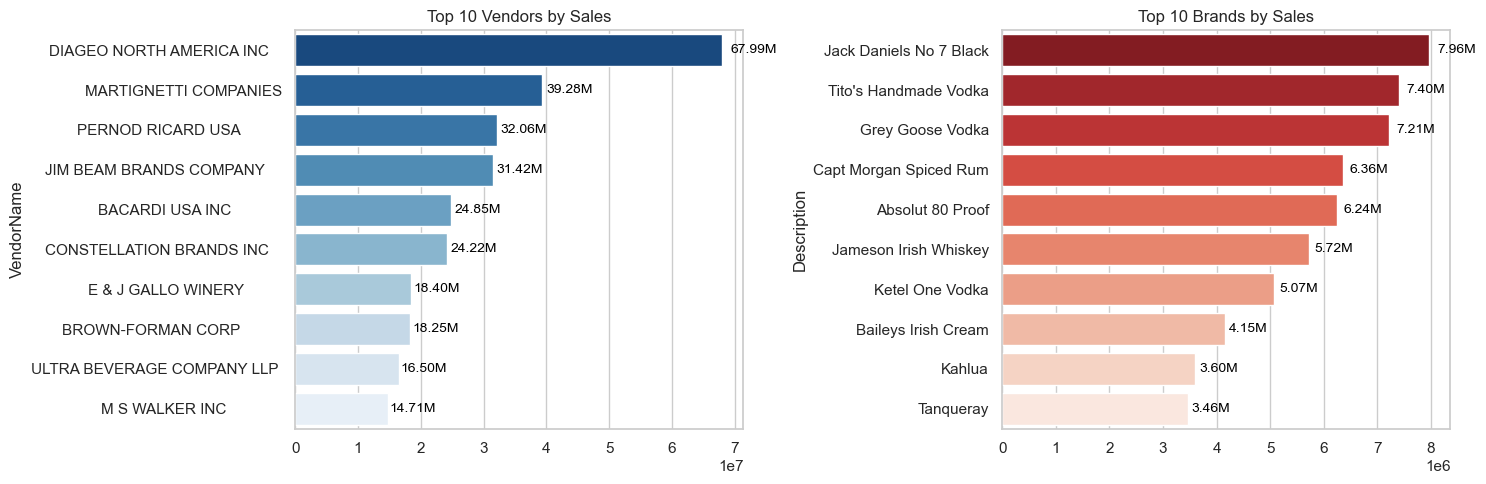

In [92]:

plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollar(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollar(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()



## Vendor Performance
Vendors contributing the most to purhcase dollars

#same table like we did before for top vendors

In [169]:
# Sorted by Gross Profit in descending order
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars': 'sum',
    'TotalSalesDollars': 'sum',
    'GrossProfit': 'sum'
}).reset_index().sort_values(by='TotalSalesDollars', ascending=False)

# Display the top vendors
vendor_performance.head()
#same table like we did before for top vendors

,VendorName,TotalPurchaseDollars,TotalSalesDollars,GrossProfit
25,DIAGEO NORTH AMERICA INC,50097226.16,67990099.42,17892873.26
57,MARTIGNETTI COMPANIES,25464774.04,39276398.80,13811624.76
69,PERNOD RICARD USA,23851164.17,32063196.19,8212032.02
46,JIM BEAM BRANDS COMPANY,23494304.32,31423020.46,7928716.14
6,BACARDI USA INC,17432020.26,24854817.14,7422796.88


##### Adding a new column 


In [170]:
vendor_performance['PurchaseContri%']=vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()*100
# vendor_performance['PurchaseContri%']=vendor_performance['PurchaseContri']*100
# % contri of sale=> his purhcase/ total purchase made
round(vendor_performance.sort_values(by='PurchaseContri%',ascending=False),2) #rounded up
#convert to millions and thousands to all 3 columns

vendor_performance['TotalPurchaseDollars']=vendor_performance['TotalPurchaseDollars'].apply(format_dollar)
vendor_performance['TotalSalesDollars']=vendor_performance['TotalSalesDollars'].apply(format_dollar)
vendor_performance['GrossProfit']=vendor_performance['GrossProfit'].apply(format_dollar)

#for top 10 contributors
top_10_vendors=round(vendor_performance.head(10),2)
top_10_vendors


,VendorName,TotalPurchaseDollars,TotalSalesDollars,GrossProfit,PurchaseContri%
25,DIAGEO NORTH AMERICA INC,50.10M,67.99M,17.89M,16.30
57,MARTIGNETTI COMPANIES,25.46M,39.28M,13.81M,8.29
69,PERNOD RICARD USA,23.85M,32.06M,8.21M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,31.42M,7.93M,7.64
6,BACARDI USA INC,17.43M,24.85M,7.42M,5.67
20,CONSTELLATION BRANDS INC,15.27M,24.22M,8.95M,4.97
30,E & J GALLO WINERY,12.07M,18.40M,6.33M,3.93
11,BROWN-FORMAN CORP,13.24M,18.25M,5.01M,4.31
107,ULTRA BEVERAGE COMPANY LLP,11.17M,16.50M,5.34M,3.63
53,M S WALKER INC,9.76M,14.71M,4.94M,3.18


In [171]:
#total no of vendors
vendor_performance.shape

(120, 5)

In [160]:
#Total contri of top 10 among 120 vendors

top_10_vendors=vendor_performance.head(10)
top_10_vendors['PurchaseContri%'].head(10).sum()
#ie contri to more than 50% ie 65%

np.float64(65.67745684582758)

In [172]:
#Cumulative Distribution

top_10_vendors['Cum_Contri%']=top_10_vendors['PurchaseContri%'].cumsum()
top_10_vendors

,VendorName,TotalPurchaseDollars,TotalSalesDollars,GrossProfit,PurchaseContri%,Cum_Contri%
25,DIAGEO NORTH AMERICA INC,50.10M,67.99M,17.89M,16.30,16.30
57,MARTIGNETTI COMPANIES,25.46M,39.28M,13.81M,8.29,24.59
69,PERNOD RICARD USA,23.85M,32.06M,8.21M,7.76,32.35
46,JIM BEAM BRANDS COMPANY,23.49M,31.42M,7.93M,7.64,39.99
6,BACARDI USA INC,17.43M,24.85M,7.42M,5.67,45.66
20,CONSTELLATION BRANDS INC,15.27M,24.22M,8.95M,4.97,50.63
30,E & J GALLO WINERY,12.07M,18.40M,6.33M,3.93,54.56
11,BROWN-FORMAN CORP,13.24M,18.25M,5.01M,4.31,58.87
107,ULTRA BEVERAGE COMPANY LLP,11.17M,16.50M,5.34M,3.63,62.50
53,M S WALKER INC,9.76M,14.71M,4.94M,3.18,65.68


## Pareta Chart(bar and line)

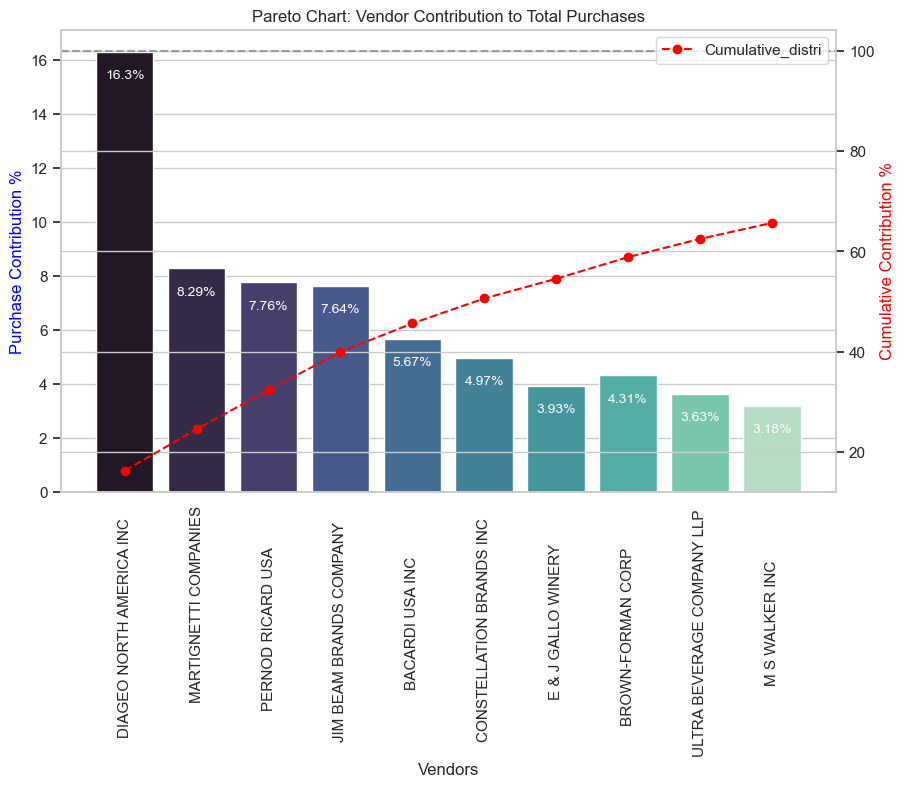

In [173]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(x=top_10_vendors['VendorName'], y=top_10_vendors['PurchaseContri%'], palette="mako", ax=ax1)

for i, value in enumerate(top_10_vendors['PurchaseContri%']):
    ax1.text(i, value - 1, str(value)+'%', ha='center', fontsize=10, color='white')
top_10_vendors['Cum_Contri%'] = top_10_vendors['PurchaseContri%'].cumsum()
# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(top_10_vendors['VendorName'], top_10_vendors['Cum_Contri%'], color='red', marker='o', linestyle='dashed', label='Cumulative_distri')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')
plt.show()

## Pie Chart

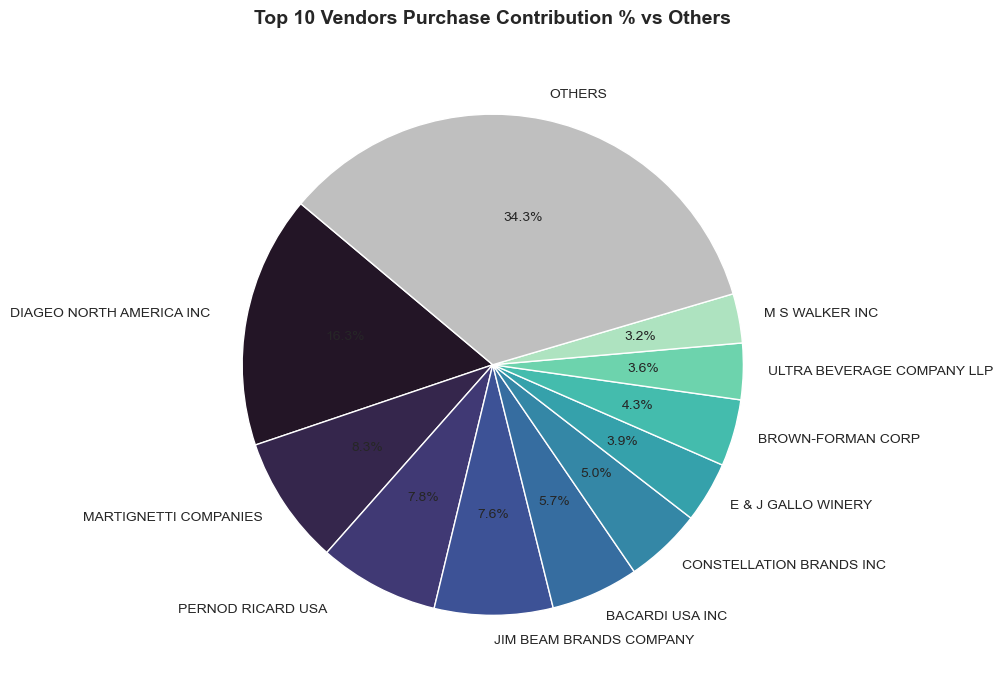

In [174]:
top_10_sum = top_10_vendors['PurchaseContri%'].sum()
others_sum = 100.0 - top_10_sum

# 2. Prepare labels and sizes for the pie chart
labels = list(top_10_vendors['VendorName']) + ['OTHERS']
sizes = list(top_10_vendors['PurchaseContri%']) + [others_sum]

# 3. Create an elegant color palette (Mako-themed blues for top 10, neutral gray for Others)
colors = sns.color_palette("mako", len(top_10_vendors))
colors.append((0.75, 0.75, 0.75)) # Adding a neutral gray for 'OTHERS'

# 4. Generate the Pie Chart
plt.figure(figsize=(10, 10))
plt.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    textprops={'fontsize': 10},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1} # Adds clean separation lines
)

# 5. Add title and display
plt.title('Top 10 Vendors Purchase Contribution % vs Others', fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()

Purchasing in bulk reduces unit price

In [189]:
df['UnitPurchasePrice']=df['TotalPurchaseDollars']/df['TotalPurchaseQuantity'] 
#df i used since we dont want grouo by vendor or brand here
df['OrderSize']=pd.qcut(df["TotalPurchaseQuantity"],q=3,labels=["small","medium","large"]) #divides purchsse quantity into 3 segments
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()


,UnitPurchasePrice
OrderSize,
small,39.068186
medium,15.486414
large,10.777625


Larger the quantity of purchasae lower is the cost price(bulk pricing = less price)
* Vendors buying in lkarge quantity get lowest price $10.78 per unit=>high tprofit if inventory is managed effciently

Vendors having low invetory turnover(ie excess stock and slow moving product)

In [196]:
# df.columns

In [ ]:
df[df['StockTurnOver']<1].groupby('VendorName')[['StockTurnOver']].mean().sort_values('StockTurnOver',ascending=True).head(10)
#having less than 1(since >1 means already present)
# grouped by vendors, mean of stockturnover for eacch
# sorted acc to stockturnibver
#first 10

,StockTurnOver
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


* Unsold inventory value
* =totalpurfhase units-total sold units for a particular brand and vendor)* its purchase price

In [199]:
df['UnsoldValue']=(df['TotalPurchaseQuantity']-df['TOtalsalesQuantity'])*df['PurchasePrice']
display('Total unsold capitwal', format_dollar(df['UnsoldValue'].sum()))


'Total unsold capitwal'

'2.71M'

In [ ]:
#Sort vendors with highest locked capital(value)
inv_vendor = df.groupby("VendorName")["UnsoldValue"].sum().reset_index()
inv_vendor = inv_vendor.sort_values(by="UnsoldValue", ascending=False)

# 2. Format ONLY the specific numeric column for display
inv_vendor['UnsoldValue'] = inv_vendor['UnsoldValue'].apply(format_dollar)

# 3. View the top vendors with locked capital
inv_vendor.head(10)

,VendorName,UnsoldValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
69,PERNOD RICARD USA,470.63K
117,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
80,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
62,MOET HENNESSY USA INC,126.48K
78,REMY COINTREAU USA INC,118.60K


* Seggregating top performing and low performing vendor based on Total Sales Dollars
* top= more than 75% total sales dollar while low= less than 25 %


In [206]:
top_threshold=df['TotalSalesDollars'].quantile(0.75)
low_threshold=df['TotalSalesDollars'].quantile(0.25)

In [ ]:
top_vendors=df[df['TotalSalesDollars']>=top_threshold]['ProfitMargin'].dropna()
low_vendors=df[df['TotalSalesDollars']<=low_threshold]['ProfitMargin'].dropna()

#many vendors with their respective profit margins distributed

In [212]:
# top_vendors

In [213]:
# low_vendors

### Confidence interval

In [211]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.18
Low Vendors 95% CI: (40.50, 42.64), Mean: 41.57


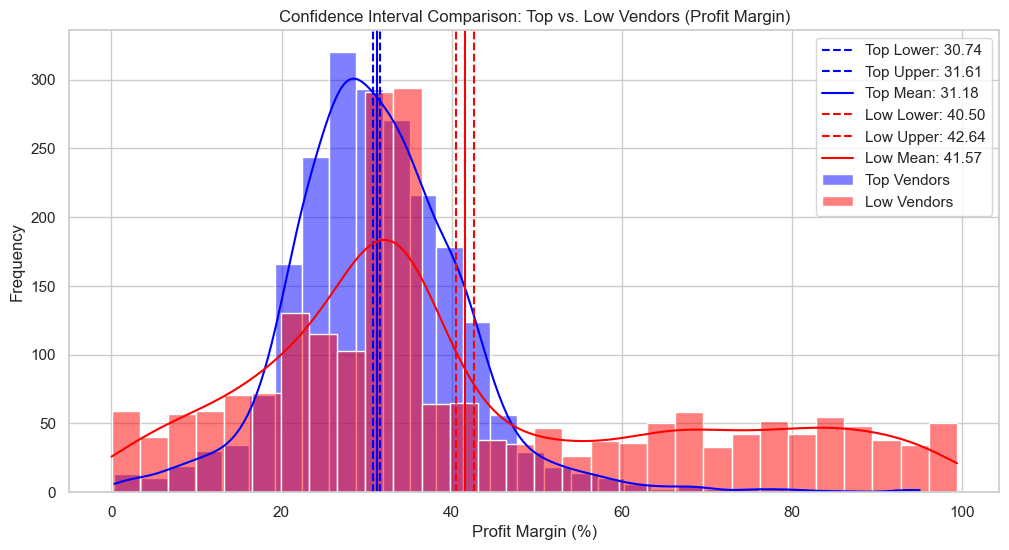

In [214]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

# Analysis

- The confidence interval for low-performing vendors (40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%).
- This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.
- **For High-Performing Vendors:** If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.
- **For Low-Performing Vendors:** Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.